# Customer Analysis

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import importlib

import src.metrics as mt
import src.common as co
import src.visualization as vs

importlib.reload(mt)
importlib.reload(co)
importlib.reload(vs)

<module 'src.visualization' from 'C:\\Users\\TUF\\OneDrive\\Documents\\Code\\Vs Code\\sales_analytics\\src\\visualization.py'>

In [3]:
sales_mart = co.fact_sales()
ckpi = mt.CustomerKPIs(sales_mart)

In [18]:
a = sales_mart[(sales_mart['year'] != 2013) & (sales_mart['year'] != 2014)]['customer_key'].nunique()

In [19]:
b = sales_mart[sales_mart['year'] != 2014]['customer_key'].nunique()

In [20]:
c = sales_mart[sales_mart['year'] != 2013]['customer_key'].nunique()

In [21]:
a, b, c

(5455, 17978, 6289)

#### High level Kpis

In [186]:
vs.customer_kpis(sales_mart)

,KPIs,Values
0,Total Customer,18.5K
1,Customer Average Order,3.3
2,Customer Average Order Value,1.6K
3,Customer Repeat Rate,86.5
4,Purchase_Frequency,1.5


#### Total Customer by Gender

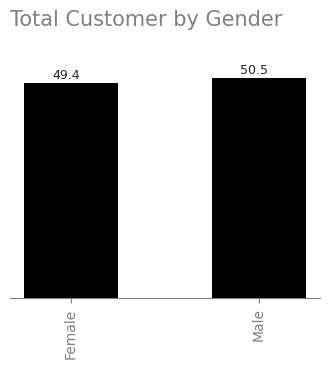

In [222]:
df = ckpi.customer_by_gender()
vs.ColumnPlotLabel(
    x= df['gender'],
    y1=df['percentage'],
    y2 = .1,
    y3= 1,
    title= 'Total Customer by Gender',
    fsize=(4,3)
).decoration()

#### Revenue by Gender

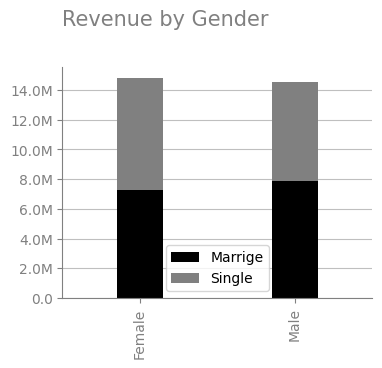

In [188]:
df = ckpi.revenue_by_gender_marital_status()
vs.StackedColumnPlot(
    x= df.index,
    y1=df['Married'],
    y2=df['Single'],
    title= 'Revenue by Gender',
    label1='Marrige',
    label2='Single',
    legend=True,
    fsize=(4,3)
    ).decoration()

#### Revenue by Customers Age Group

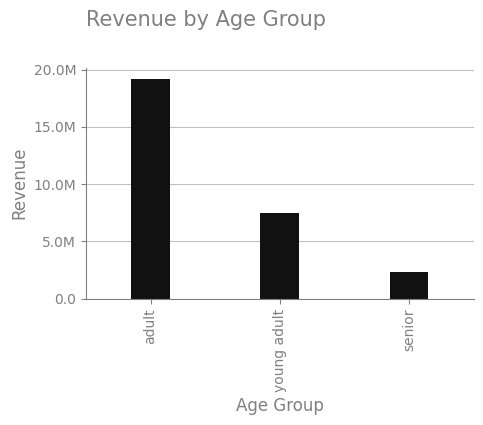

In [174]:
df = ckpi.revenue_by_customer_age_group()
vs.ColumnPlot(
    x=df['age_group'],
    y1=df['revenue'],
    title= 'Revenue by Age Group',
    xlable='Age Group',
    ylable= 'Revenue',
    fsize=(5,3)
).decoration()

#### Customer by Country's

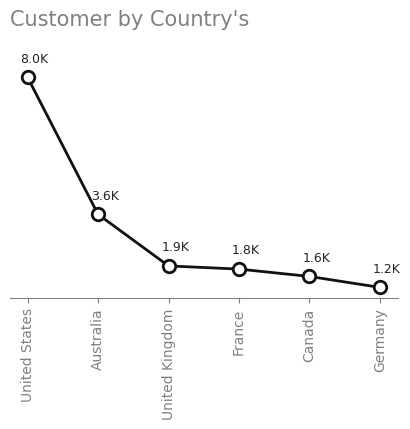

In [ ]:
df = ckpi.customer_across_country()
vs.LinePlotLabel(
    x = df['country'],
    y1 = df['total_customer'],
    y2 = .1,
    y3 = 500,
    title= "Customer by Country's",
    fsize=(5,3)
).decoration()

#### Top 50 Customer by Revenue

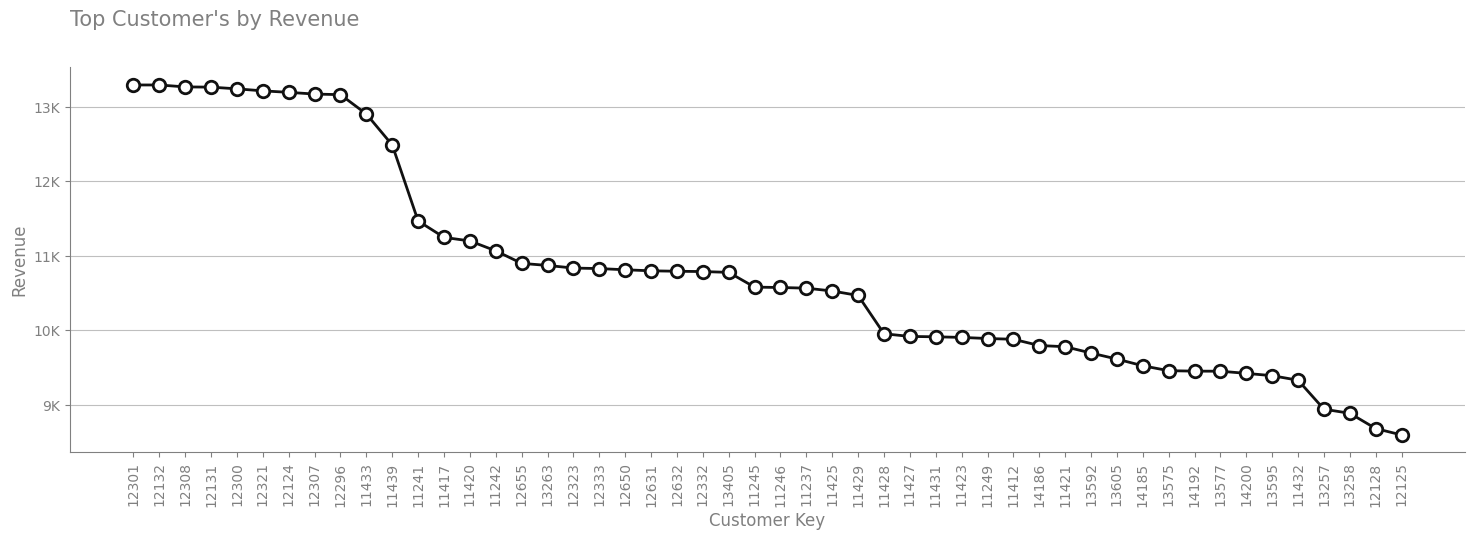

In [178]:
df = ckpi.customer_revenue().head(50)
x = df['customer_key'].apply(lambda x: str(x))
vs.LinePlot(
    x = x,
    y1 = df['customer_revenue'],
    title= "Top Customer's by Revenue",
    xlable='Customer Key',
    ylable='Revenue',
    fsize=(18,5)
).decoration()